#Customer Segmentation using K-Means Clustering

#Problem Statement

Group customers into different segments based on their behavior and features like age, income, and spending score.

#Features:

1) Upload any CSV                                     
2) Auto select numeric columns                        
3) Handle missing values                              
4) Auto find best K (Elbow)                           
5) Show graph                                         
6) Save output file                                  

 Upload any CSV file


Saving ML_TYPE_2_DATASET_PROJECT.csv to ML_TYPE_2_DATASET_PROJECT (2).csv

 Dataset Loaded Successfully!

 First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

 Numeric Columns Used:
Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

 Missing values removed!


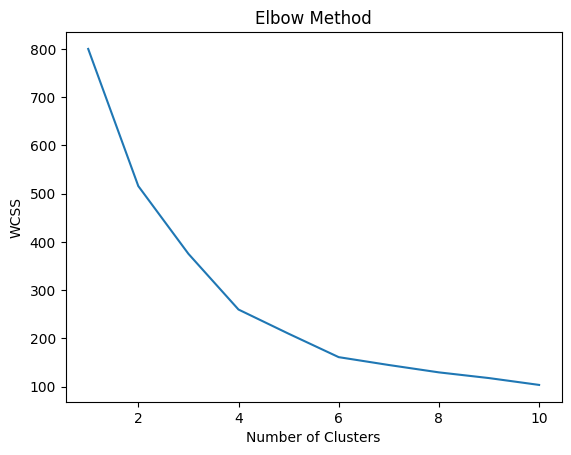


 Applying K-Means with K = 3

 Silhouette Score: 0.34

 Cluster Insights (Mean Values):
         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         41.384615  26.807692           34.884615               59.211538
1         73.112903  54.983871           49.419355               40.338710
2        155.988372  34.500000           84.116279               51.860465


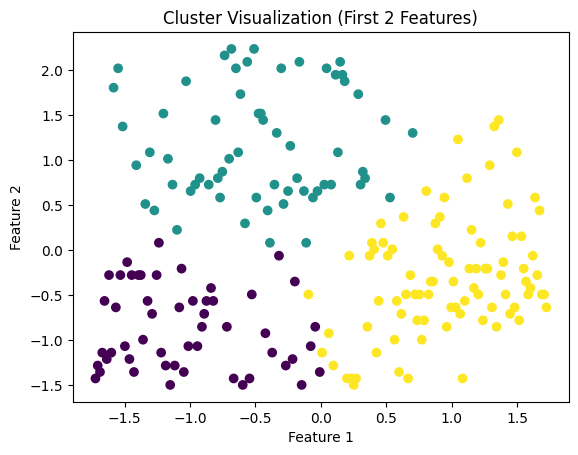


 File Ready: clustered_output.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
#  AUTOMATIC K-MEANS CLUSTERING PROJECT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# -----------------------------
# Upload File
# -----------------------------
from google.colab import files

print(" Upload any CSV file")
uploaded = files.upload()

# Get file name
file_name = list(uploaded.keys())[0]

# Load data
data = pd.read_csv(file_name)

print("\n Dataset Loaded Successfully!")
print("\n First 5 rows:")
print(data.head())

# -----------------------------
# Select Numeric Columns
# -----------------------------
numeric_data = data.select_dtypes(include=[np.number])

print("\n Numeric Columns Used:")
print(numeric_data.columns)

# -----------------------------
# Handle Missing Values
# -----------------------------
numeric_data = numeric_data.dropna()

print("\n Missing values removed!")

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_data)

# -----------------------------
# Elbow Method (Find K)
# -----------------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# -----------------------------
# Choose K
# -----------------------------
k = 3  # Change based on elbow graph

print(f"\n Applying K-Means with K = {k}")

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
data = data.loc[numeric_data.index]
data['Cluster'] = clusters

# -----------------------------
# Evaluation
# -----------------------------
score = silhouette_score(X_scaled, clusters)
print(f"\n Silhouette Score: {score:.2f}")

# -----------------------------
# Insights
# -----------------------------
print("\n Cluster Insights (Mean Values):")
cluster_summary = data.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

# -----------------------------
# Visualization
# -----------------------------
if X_scaled.shape[1] >= 2:
    plt.figure()
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
    plt.title("Cluster Visualization (First 2 Features)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
else:
    print("\n Not enough features to plot graph")

# -----------------------------
# Save Output
# -----------------------------
output_file = "clustered_output.csv"
data.to_csv(output_file, index=False)

print(f"\n File Ready: {output_file}")

files.download(output_file)